**Feature Engineering**

Feature engineering is the process of creating, transforming or selecting the most relevant variables (features) from raw data to improve model performance


**Feature Engineering Pointings**

**Handling missing values**
Filling (mean, median, mode), interpolation, or marking missingness with a flag

**Outlier detection and treatment**
Identifying extreme values and removing, capping, or transforming them

**Feature scaling**
Normalization, standardization, min-max scaling

**Feature transformation**
Log, square root, Box-Cox, power transforms

**Encoding categorical variables**
Label encoding, one-hot encoding, target encoding

**Feature creation**
Creating new features from existing data (ratios, interactions, aggregations)

**Feature selection**
Removing irrelevant, redundant, or highly correlated features

**Dimensionality reduction**
PCA, LDA, autoencoders

**Binning / discretization**
Converting continuous variables into intervals or groups

**Handling imbalanced data**
Oversampling, undersampling, SMOTE

**Noise reduction**
Smoothing, filtering, removing inconsistent data

**Date and time feature extraction**
Day, month, year, weekday, lag features

**Feature Scaling**

Feature scaling is a critical machine learning preprocessing step that transforms numerical features to a common range or distribution (e.g., 0 to 1, or mean 0, variance 1). It prevents features with large magnitudes from dominating models, ensures equitable feature contribution, and accelerates convergence for distance-based and gradient-based algorithms. 

**Why Feature Scaling is Necessary**
Machine learning algorithms are sensitive to the scale of data. Without scaling, features with larger numeric ranges (e.g., annual income in thousands) can overshadow features with smaller ranges (e.g., age). 
Distance-Based Algorithms: Algorithms like KNN, K-Means, and SVM rely on distance calculations, so larger magnitudes heavily bias the model.


**Gradient Descent Optimization**: Models like Linear Regression, Logistic Regression, and Neural Networks converge much faster when features are scaled.


**Model Performance**: Proper scaling improves the stability and accuracy of the model, preventing it from being biased towards specific features. 

**What is Standardization (in simple words)?**

Different columns live on different planets:  
  Glucose → values ~ 70–200  
  Age → values ~ 20–80  
  DiabetesPedigreeFunction → values ~ 0–2  

ML models get confused when one feature shouts and another whispers.  

Standardization fixes this by making:  
Mean = 0  
Standard deviation = 1  

x(scaled)=x-x(mean)/standard_deviation


In [1]:
import pandas as pd

data = pd.read_csv('diabetes.csv')
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1


In [9]:
X = data.drop(columns=["Outcome"])   # features
y = data["Outcome"]   

In [10]:
print(X.shape)
print(data.shape)

(768, 8)
(768, 9)


In [8]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [16]:
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)


In [17]:
X_scaled.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0.639947,0.864625,-0.032180,0.665181,0.311604,0.169483,0.468492,1.425995
1,-0.844885,-1.204727,-0.528124,-0.010112,-0.440843,-0.848549,-0.365061,-0.190672
2,1.233880,2.014265,-0.693438,0.327535,0.311604,-1.328478,0.604397,-0.105584
3,-0.844885,-1.073339,-0.528124,-0.685405,-0.536303,-0.630399,-0.920763,-1.041549
4,-1.141852,0.503310,-2.677212,0.665181,0.294758,1.551096,5.484909,-0.020496


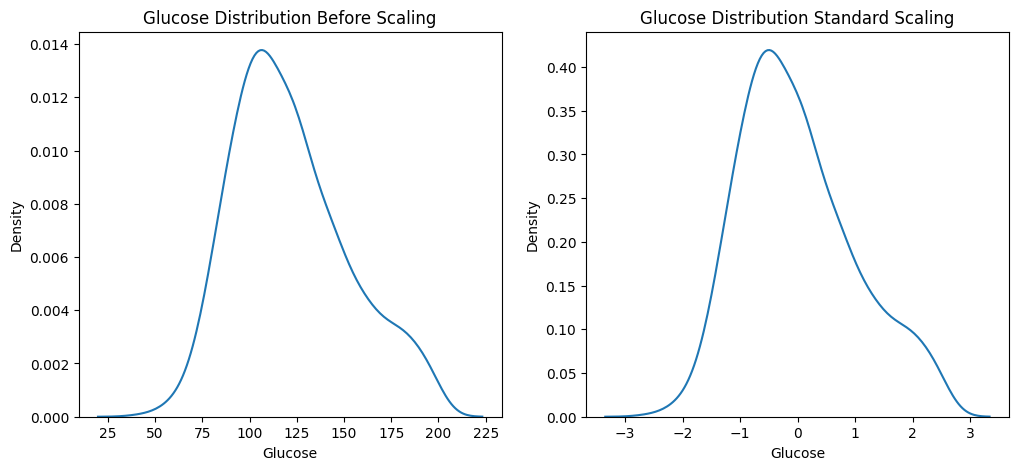

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Glucose Distribution Before Scaling')
sns.kdeplot(data['Glucose'], ax=ax1)

# after scaling
ax2.set_title('Glucose Distribution Standard Scaling')
sns.kdeplot(X_scaled['Glucose'], ax=ax2)
plt.show()

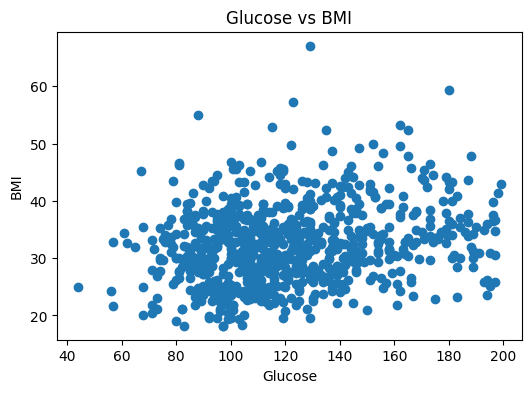

In [54]:
#Before Stanardard Scaling
plt.figure(figsize=(6, 4))
plt.scatter(data["Glucose"], data["BMI"])
plt.xlabel("Glucose")
plt.ylabel("BMI")
plt.title("Glucose vs BMI")
plt.show()

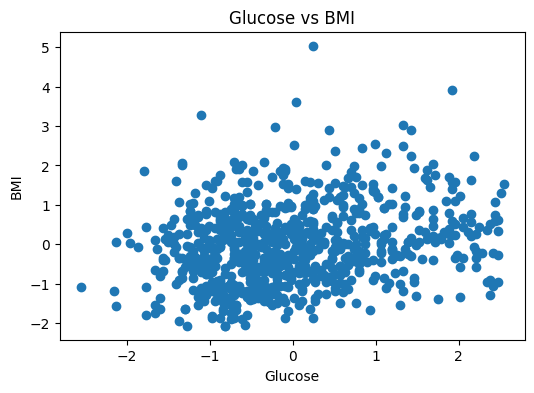

In [55]:
#After Standard Scaling
plt.figure(figsize=(6, 4))
plt.scatter(X_scaled["Glucose"], X_scaled["BMI"])
plt.xlabel("Glucose")
plt.ylabel("BMI")
plt.title("Glucose vs BMI")
plt.show()